In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import MinMaxScaler

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

In [2]:
#df = pd.read_excel("CustomerChurn_data.xlsx")
#print(df.info())
#print(df.head())
#print(df.describe())

#for col in df.columns:

#  print(col, "->", df[col].unique())

# Processing Data

In [3]:
def process_data(filename, /):

  if not isinstance(filename, str):

    raise TypeError

  df = pd.read_excel(filename)

  df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

  df.dropna(inplace = True)

  df.drop_duplicates(inplace = True)

  df.reset_index(drop = True, inplace = True)

  df.drop("customerID", axis = 1, inplace = True)

  df["gender"] = df["gender"].apply(lambda x: 1 if x == "Female" else 0)

  yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

  df[yes_no_cols] = df[yes_no_cols].map(lambda x: 1 if x == "Yes" else 0)

  cols_to_encode = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaymentMethod"]

  scaler = MinMaxScaler()

  feature_cols = df.drop(cols_to_encode + ["Churn"], axis = 1).columns

  df[feature_cols] = scaler.fit_transform(df[feature_cols])

  return df

In [4]:
df = process_data("CustomerChurn_data.xlsx")
print(df.head())

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     1.0            0.0      1.0         0.0  0.000000           0.0   
1     0.0            0.0      0.0         0.0  0.464789           1.0   
2     0.0            0.0      0.0         0.0  0.014085           1.0   
3     0.0            0.0      0.0         0.0  0.619718           0.0   
4     1.0            0.0      0.0         0.0  0.014085           1.0   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1 

In [5]:
print(df["Churn"].value_counts()[0], "negative instances")
print(df["Churn"].value_counts()[1], "positive instances")

5163 negative instances
1869 positive instances


# Training, Validation & Testing

In [6]:
y_target = df["Churn"]
X_data = df.drop("Churn", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_target,
    test_size = 0.2, # 20% for testing
    random_state = 42,
    stratify = y_target
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size = 0.125,       #10% of training for validation
    random_state = 42,
    stratify = y_train
    )

print("//--------Training Data---------//")
print(len(X_train), "total instances")
print("->", y_train.value_counts()[0], "negative instances")
print("->", y_train.value_counts()[1], "positive instances\n")

print("//--------Validation Data---------//")
print(len(X_val), "total instances")
print("->", y_val.value_counts()[0], "negative instances")
print("->", y_val.value_counts()[1], "positive instances\n")

print("//--------Testing Data---------//")
print(len(X_test), "total instances")
print("->", y_test.value_counts()[0], "negative instances")
print("->", y_test.value_counts()[1], "positive instances")

//--------Training Data---------//
4921 total instances
-> 3613 negative instances
-> 1308 positive instances

//--------Validation Data---------//
704 total instances
-> 517 negative instances
-> 187 positive instances

//--------Testing Data---------//
1407 total instances
-> 1033 negative instances
-> 374 positive instances


In [7]:
# Applying Oversampling (SMOTE)

cols_to_encode = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling",
                  "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaymentMethod"]

col_ids = [X_train.columns.get_loc(col) for col in cols_to_encode]

smote = SMOTENC(
    categorical_features = col_ids,
    random_state = 42
)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("//--------Training Data---------//")
print(len(X_train), "total instances")
print("->", y_train.value_counts()[0], "negative instances")
print("->", y_train.value_counts()[1], "positive instances\n")
print(X_train.iloc[0], "\n")
print(X_train.iloc[len(X_train)-1])
print(y_train.iloc[len(y_train)-1])

//--------Training Data---------//
7226 total instances
-> 3613 negative instances
-> 3613 positive instances

gender                              1.0
SeniorCitizen                       0.0
Partner                             0.0
Dependents                          0.0
tenure                         0.112676
PhoneService                        1.0
MultipleLines                        No
InternetService                      No
OnlineSecurity      No internet service
OnlineBackup        No internet service
DeviceProtection    No internet service
TechSupport         No internet service
StreamingTV         No internet service
StreamingMovies     No internet service
Contract                 Month-to-month
PaperlessBilling                    0.0
PaymentMethod              Mailed check
MonthlyCharges                   0.0199
TotalCharges                   0.019311
Name: 0, dtype: object 

gender                           1.0
SeniorCitizen                    0.0
Partner                       

In [8]:
def encode_features(df):

  cols_to_encode = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaymentMethod"]
  df = pd.get_dummies(df, columns = cols_to_encode)

  dummy_cols = df.select_dtypes(include = "bool").columns

  df[dummy_cols] = df[dummy_cols].astype(float)

  return df

In [9]:
X_train = encode_features(X_train)
X_val =  encode_features(X_val)
X_test = encode_features(X_test)

print(X_train.head())

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     1.0            0.0      0.0         0.0  0.112676           1.0   
1     0.0            0.0      0.0         0.0  0.056338           1.0   
2     0.0            0.0      1.0         1.0  0.169014           1.0   
3     1.0            0.0      0.0         0.0  0.070423           0.0   
4     0.0            0.0      0.0         0.0  0.056338           1.0   

   PaperlessBilling  MonthlyCharges  TotalCharges  MultipleLines_No  ...  \
0               0.0        0.019900      0.019311               1.0  ...   
1               0.0        0.854229      0.060362               0.0  ...   
2               1.0        0.780100      0.132016               1.0  ...   
3               1.0        0.295522      0.033037               0.0  ...   
4               1.0        0.307960      0.022859               1.0  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 0.0                     

In [10]:
x_train = torch.from_numpy(X_train.values).float()
x_val = torch.from_numpy(X_val.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).float()
#print(y_train)
y_train = y_train.reshape(-1, 1) # shape(kx1)
#print(y_train)

y_val = torch.from_numpy(y_val.values).float()
#print(y_val)
y_val = y_val.reshape(-1, 1) # shape(kx1)
#print(y_val)

y_test = torch.from_numpy(y_test.values).float()
#print(y_test)
y_test = y_test.reshape(-1, 1) # shape(kx1)
#print(y_test)

# Adding Bias term
x_train = torch.cat([x_train, torch.ones(x_train.size(0), 1)], dim = 1)
x_val = torch.cat([x_val, torch.ones(x_val.size(0), 1)], dim = 1)
x_test = torch.cat([x_test, torch.ones(x_test.size(0), 1)], dim = 1)

print("Number of Features: {}".format(x_train.shape[1]))
print(x_train[0])
print(y_train[0])

Number of Features: 41
tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.1127, 1.0000, 0.0000, 0.0199, 0.0193,
        1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000,
        0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000,
        0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 1.0000, 1.0000])
tensor([0.])


In [11]:
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = True)

for batch_x, batch_y in train_loader:

  print(batch_x)
  break

tensor([[0., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 0.,  ..., 0., 0., 1.],
        [1., 1., 0.,  ..., 1., 0., 1.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 1.],
        [1., 0., 1.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.]])


# Classification Model

In [12]:
def logreg(X, w):

  return torch.matmul(X, w.T)

# Training Model

In [13]:
def compute_metrics(true_labels, pred_labels):

  tp, fp = 0, 0
  tn, fn = 0, 0

  for true, pred in zip(true_labels, pred_labels):

    if true == 1 and pred == 1:

      tp += 1

    elif true == 0 and pred == 0:

      tn += 1

    elif true == 0 and pred == 1:

      fp += 1

    else:

      fn += 1

  accuracy = (tp + tn) / (tp + tn + fp + fn)
  precision = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall = tp / (tp + fn) if (tp + fn) > 0 else 0
  f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

  return accuracy, precision, recall, f1_score

In [14]:
w = torch.zeros(size = (1, x_train.shape[1]), requires_grad = True)
loss = torch.nn.BCEWithLogitsLoss()
lr = 0.01
optimizer = torch.optim.SGD([w], lr = lr, weight_decay = 0.01)

In [15]:
def train(train_loader, val_loader, w, optimizer, loss, num_epochs):

  train_accs, val_accs = [], []
  train_losses, val_losses = [], []

  for epoch in range(num_epochs):

    epoch_acc = 0
    epoch_loss = 0

    print(f'\nEpoch {epoch + 1}/{num_epochs}.')

    for batch_x, batch_y in train_loader:

      train_logits = logreg(batch_x, w)

      train_loss = loss(train_logits, batch_y)

      optimizer.zero_grad()

      train_loss.backward()

      optimizer.step()

      train_preds = torch.sigmoid(train_logits) > 0.5

      train_acc, _, _, _ = compute_metrics(batch_y, train_preds)

      epoch_loss += train_loss.item()
      epoch_acc += train_acc

    train_accs.append(epoch_acc / len(train_loader))
    train_losses.append(epoch_loss / len(train_loader))

    print("Train Loss:{}, Acc:{}".format(train_losses[-1], train_accs[-1] * 100))

    epoch_acc = 0
    epoch_loss = 0

    with torch.no_grad():

      for batch_x, batch_y in val_loader:

        val_logits = logreg(batch_x, w)

        val_loss = loss(val_logits, batch_y)

        val_preds = torch.sigmoid(val_logits) > 0.5

        val_acc, _, _, _ = compute_metrics(batch_y, val_preds)

        epoch_loss += val_loss.item()
        epoch_acc += val_acc

    val_accs.append(epoch_acc / len(val_loader))
    val_losses.append(epoch_loss / len(val_loader))

    print("Val Loss:{}, Acc:{}".format( val_losses[-1], val_accs[-1] * 100))

  #------Plotting Loss and Accuracy Values---------
  plt.figure(figsize = (12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(train_losses, label = "Training Loss")
  plt.legend(loc = "best")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")

  plt.subplot(1, 2, 2)
  plt.plot(val_losses, label = "Validation Loss")
  plt.legend(loc = "best")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")

  plt.tight_layout()
  plt.show()

  plt.plot(train_accs, label = "Training accuracy")
  plt.plot(val_accs, label = "Validation accuracy")
  plt.legend(loc = "best")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy(%)")

  plt.show()


Epoch 1/15.
Train Loss:0.6389411793345898, Acc:74.04113899908454
Val Loss:0.6283944194967096, Acc:68.32386363636364

Epoch 2/15.
Train Loss:0.5711935315511923, Acc:76.0985657613671
Val Loss:0.5841865322806619, Acc:71.02272727272727

Epoch 3/15.
Train Loss:0.5352940931256893, Acc:77.04169209642967
Val Loss:0.565418237989599, Acc:71.30681818181817

Epoch 4/15.
Train Loss:0.5141217821994714, Acc:77.38213304851999
Val Loss:0.5455822754989971, Acc:71.30681818181817

Epoch 5/15.
Train Loss:0.5004911385806261, Acc:77.78026777540433
Val Loss:0.5363272103396329, Acc:71.5909090909091

Epoch 6/15.
Train Loss:0.49113291554746374, Acc:78.05109475129693
Val Loss:0.5287163067947734, Acc:72.01704545454545

Epoch 7/15.
Train Loss:0.4844346600296223, Acc:78.11451022276474
Val Loss:0.5241473371332342, Acc:72.30113636363636

Epoch 8/15.
Train Loss:0.47932899894967546, Acc:78.3014189807751
Val Loss:0.522253158417615, Acc:72.58522727272727

Epoch 9/15.
Train Loss:0.475373401051074, Acc:78.54077662496185
Va

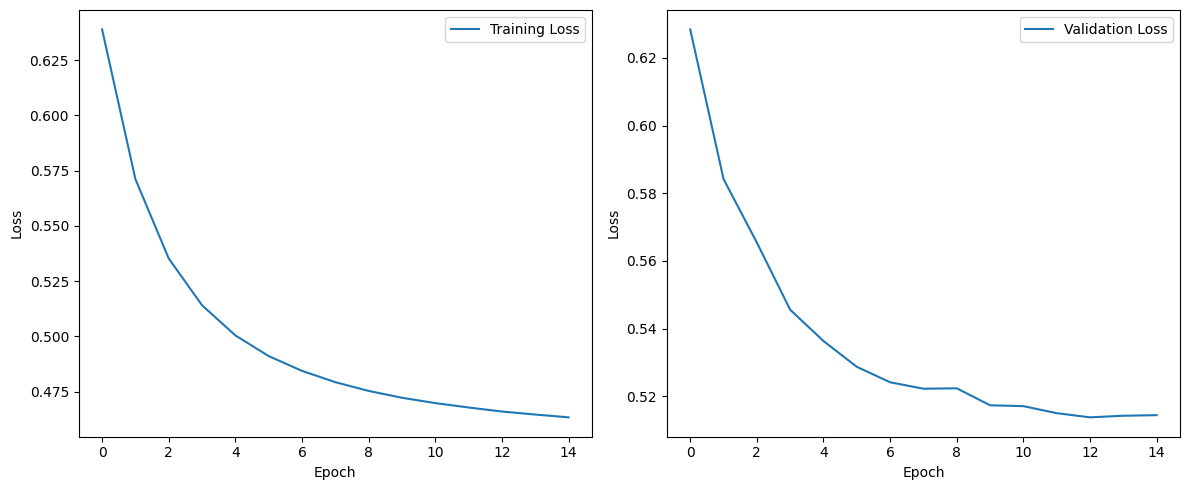

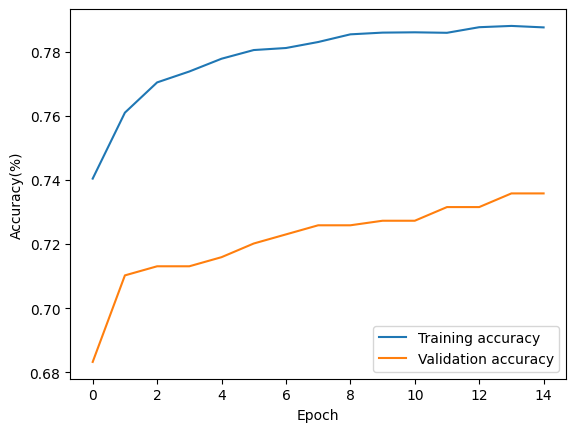

In [16]:
train(train_loader, val_loader, w, optimizer, loss, num_epochs = 15)

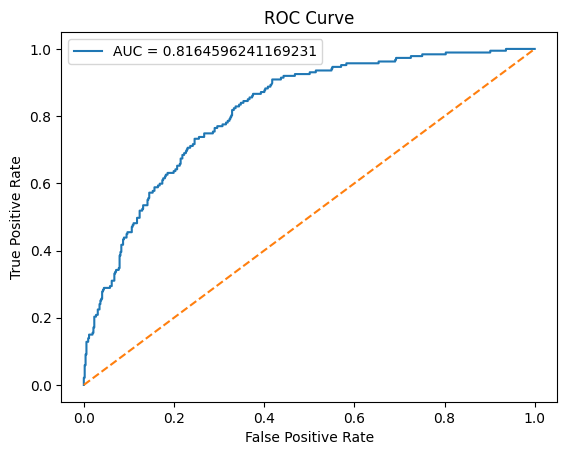

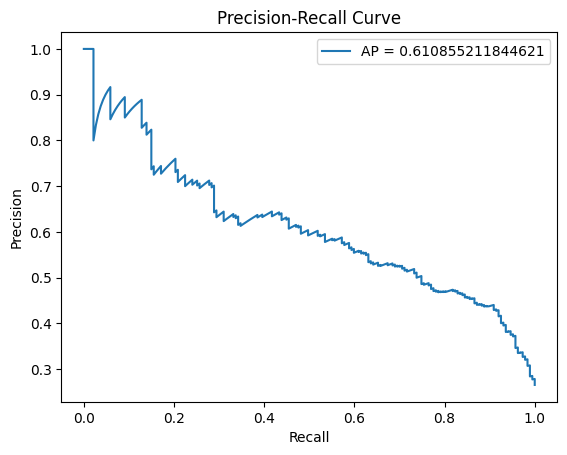

In [17]:
with torch.no_grad():

  val_logits = logreg(x_val, w)

fpr, tpr, thresholds = roc_curve(y_val, val_logits)
precision, recall, thresholds = precision_recall_curve(y_val, val_logits)

auc_score = roc_auc_score(y_val, val_logits)
ap_score = average_precision_score(y_val, val_logits)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {auc_score}")
plt.plot([0, 1], [0, 1], linestyle = "--")  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Evaluating Model

In [18]:
def eval(x_test, y_test, w, loss):

    with torch.no_grad():

      logits = logreg(x_test, w)

      l = loss(logits, y_test)

    preds = torch.sigmoid(logits) > 0.5

    accuracy, precision, recall, f1_score = compute_metrics(y_test, preds)
    auc_score = roc_auc_score(y_test, logits)

    print("Test Loss:{}\n".format(l.item()))
    print("Accuracy:{}".format(accuracy * 100))
    print("Precision:{}".format(precision))
    print("Recall:{}".format(recall))
    print("F1-Score:{}".format(f1_score))
    print("AUC score:{}".format(auc_score))

In [19]:
#print(w)
eval(x_test, y_test, w, loss)

Test Loss:0.5156159400939941

Accuracy:73.34754797441366
Precision:0.49912739965095987
Recall:0.7647058823529411
F1-Score:0.6040126715945089
AUC score:0.8184781877196887


# Saving Model Weights

In [20]:
#torch.save(w, "model_weights.pt")